# Customer Segmentation Analysis using RFM and K-Means Clustering

## Objective

The objective of this project is to segment customers based on their purchasing behaviour using RFM analysis and K-Means clustering.
The resulting customer segments can help businesses develop targeted marketing strategies.

In [76]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

In [78]:
df = pd.read_excel(r'D:\Intern\OIBSIP\L1_T_2_Customer Segmentation Analysis\Online Retail.xlsx')
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [80]:
df.shape

(541909, 8)

In [81]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[us]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  str           
dtypes: datetime64[us](1), float64(2), int64(1), object(3), str(1)
memory usage: 33.1+ MB


In [40]:
df.isnull().sum()

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

## Data Cleaning

CustomerID is essential for customer segmentation.Transactions with missing CustomerID values cannot be assigned to individual customers,
so these records will be removed before performing RFM analysis.

In [82]:
df = df.dropna(subset=['CustomerID'])
df.isnull().sum()

InvoiceNo      0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
UnitPrice      0
CustomerID     0
Country        0
dtype: int64

In [83]:
df.duplicated().sum()

np.int64(5225)

In [84]:
df = df.drop_duplicates()
df.duplicated().sum()

np.int64(0)

In [85]:
df.shape

(401604, 8)

### Duplicate Check

The dataset contained 5,268 duplicate records. 
These duplicate rows were removed to avoid overestimating customer purchase frequency and monetary value during RFM analysis.

In [86]:
df = df.drop_duplicates()

In [87]:
df.duplicated().sum()

np.int64(0)

In [88]:
df.shape

(401604, 8)

In [89]:
df.isnull().sum()

InvoiceNo      0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
UnitPrice      0
CustomerID     0
Country        0
dtype: int64

### Cancelled and Invalid Transaction Check

Before performing RFM analysis, cancelled orders, returns,
and invalid transaction values are checked to ensure that customer purchasing behaviour is measured accurately.

In [90]:
cancelled_orders = df [df['InvoiceNo'].astype(str).str.startswith('C')]
cancelled_orders.shape


(8872, 8)

In [91]:
(df['Quantity']<=0).sum()

np.int64(8872)

In [92]:
(df['UnitPrice']<=0).sum()

np.int64(40)

### Remove Cancelled and Invalid Transactions

Cancelled orders and transactions with non-positive quantity or unit price are excluded from the RFM analysis because they do not represent valid customer purchases.

In [93]:
df = df [~(df['InvoiceNo'].astype(str).str.startswith('C')) & 
    (df['Quantity']> 0) & (df['UnitPrice'])> 0].copy()

In [94]:
print('cancelled_invoice:', df['InvoiceNo'].astype(str).str.startswith('C').sum())
print('Quantity <=0:', (df['Quantity'] <=0).sum())
print('UnitPrice <=0:', (df['UnitPrice'] <=0).sum())
print('Cleaned dataset shape:',df.shape)


cancelled_invoice: 0
Quantity <=0: 0
UnitPrice <=0: 0
Cleaned dataset shape: (392692, 8)


In [95]:
df['TotalPrice'] = df['Quantity'] * df['UnitPrice']
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalPrice
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34


In [57]:
df['TotalPrice'].describe()

count    392692.000000
mean         22.631500
std         311.099224
min           0.001000
25%           4.950000
50%          12.450000
75%          19.800000
max      168469.600000
Name: TotalPrice, dtype: float64

### Descriptive Statistics

Key purchasing metrics such as average purchase value, purchase frequency,
and customer lifetime value are calculated to better understand customer purchasing behaviour.

In [96]:
invoice_totals = df.groupby('InvoiceNo')['TotalPrice'].sum()
average_purchase_value = invoice_totals.mean()
print('average_purchase_value:',round(average_purchase_value,2))

average_purchase_value: 479.56


**Observation:**  
The average purchase value is approximately 479.56, indicating that customers spend around 479.56 per order on average.

In [97]:
purchase_frequency = df.groupby('CustomerID')['InvoiceNo'].nunique()
purchase_frequency.head()

CustomerID
12346.0    1
12347.0    7
12348.0    4
12349.0    1
12350.0    1
Name: InvoiceNo, dtype: int64

In [68]:
average_purchase_frequency = purchase_frequency.mean()
print('average_purchase_frequency:',round(average_purchase_frequency,2))

average_purchase_frequency: 4.27


**Observation:**  
The average purchase frequency is 4.27 orders per customer,
indicating that each customer made approximately four purchases on average during the observed period.

In [98]:
customer_lifetime_value = df.groupby('CustomerID')['TotalPrice'].sum()
customer_lifetime_value.head()

CustomerID
12346.0    77183.60
12347.0     4310.00
12348.0     1797.24
12349.0     1757.55
12350.0      334.40
Name: TotalPrice, dtype: float64

In [72]:
average_clv = customer_lifetime_value.mean()
print('Average Customer Lifetime Value:',round(average_clv,2))

Average Customer Lifetime Value: 2048.69


**Observation:**  
The average historical customer lifetime value is approximately 2,048.69.
This means that, during the observed period, each customer generated an average total revenue of about 2,048.69.

In [99]:
print('First Transaction Date:', df['InvoiceDate'].min())
print('Last Transaction Date:', df['InvoiceDate'].max())

First Transaction Date: 2010-12-01 08:26:00
Last Transaction Date: 2011-12-09 12:50:00


In [105]:
snapshot_date = df['InvoiceDate'].max() + pd.Timedelta(days=1)
print('Snapshot Date:',snapshot_date)


Snapshot Date: 2011-12-10 12:50:00


In [107]:
rfm = df.groupby('CustomerID').agg(
    Recency= ('InvoiceDate', lambda x: (snapshot_date - x.max()).days),
    Frequency = ('InvoiceNo','nunique'),
    Monetary = ('TotalPrice','sum')).reset_index()
rfm.head()


,CustomerID,Recency,Frequency,Monetary
0,12346.0,326,1,77183.60
1,12347.0,2,7,4310.00
2,12348.0,75,4,1797.24
3,12349.0,19,1,1757.55
4,12350.0,310,1,334.40


In [108]:
rfm [['Recency','Frequency','Monetary']].describe()

,Recency,Frequency,Monetary
count,4338.000000,4338.000000,4338.000000
mean,92.536422,4.272015,2048.688081
std,100.014169,7.697998,8985.230220
min,1.000000,1.000000,3.750000
25%,18.000000,1.000000,306.482500
50%,51.000000,2.000000,668.570000
75%,142.000000,5.000000,1660.597500
max,374.000000,209.000000,280206.020000


### RFM Distribution and Outlier Analysis

The descriptive statistics indicate that Frequency and Monetary contain extreme values.
The distributions are visualized before scaling and clustering to assess skewness and potential outliers.

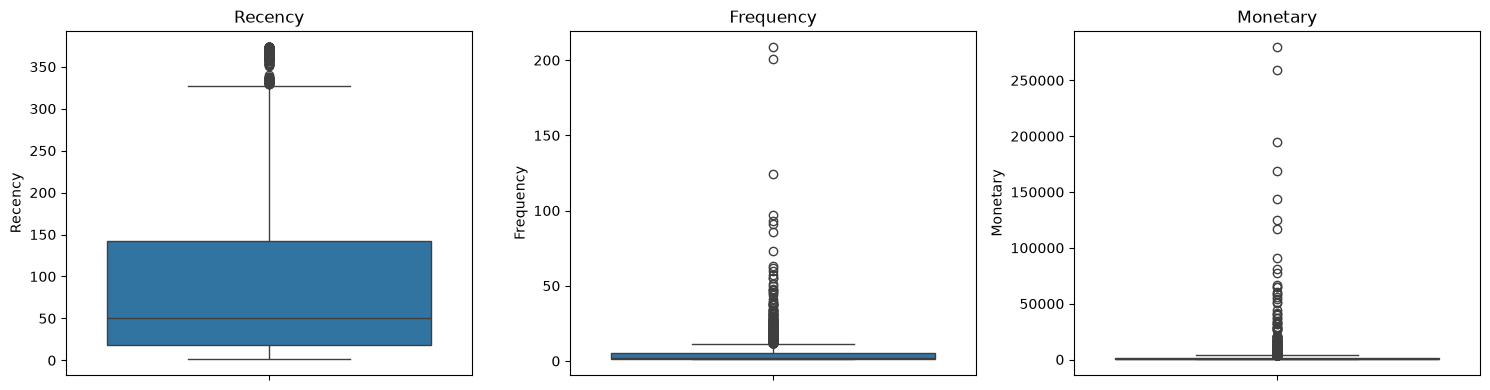

In [109]:
fig, axes = plt.subplots(1,3,figsize=(15,4))
sns.boxplot(y=rfm['Recency'], ax=axes[0])
axes[0].set_title('Recency')

sns.boxplot(y=rfm['Frequency'], ax=axes[1])
axes[1].set_title('Frequency')

sns.boxplot(y=rfm['Monetary'], ax=axes[2])
axes[2].set_title('Monetary')

plt.tight_layout()
plt.show()

### Log Transformation

The RFM features, particularly Frequency and Monetary, are highly right-skewed and contain extreme values. 
Instead of removing high-value customers,a log transformation is applied to reduce the influence of extreme values while retaining all customers for segmentation.

In [ ]:
### Feature Standardization

The log-transformed RFM features are standardized using StandardScaler. Standardization ensures that Recency, Frequency,
and Monetary contribute fairly to the K-Means clustering algorithm despite having different measurement scales.

In [111]:
rfm_log = np.log1p(rfm[['Recency', 'Frequency', 'Monetary']])
rfm_log.head()

,Recency,Frequency,Monetary
0,5.789960,0.693147,11.253955
1,1.098612,2.079442,8.368925
2,4.330733,1.609438,7.494564
3,2.995732,0.693147,7.472245
4,5.739793,0.693147,5.815324


### Feature Standardization

The log-transformed RFM features are standardized using StandardScaler. Standardization ensures that Recency, Frequency,
and Monetary contribute fairly to the K-Means clustering algorithm despite having different measurement scales.

In [122]:
scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm_log)
rfm_scaled[:5]

array([[ 1.46199281, -0.95521426,  3.7077163 ],
       [-2.03873442,  1.07442519,  1.41490344],
       [ 0.37310424,  0.38630445,  0.72002428],
       [-0.62308592, -0.95521426,  0.70228691],
       [ 1.42455753, -0.95521426, -0.61451388]])

## K-Means Clustering

The Elbow Method is used to determine an appropriate number of customer clusters. The within-cluster sum of squares (inertia) is calculated for different values of K,
and the elbow point is examined to select the optimal number of clusters.

In [114]:
# Apply the Elbow Method
inertia = []
K = range(1, 11)
for k in K:
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10)

    kmeans.fit(rfm_scaled)
    inertia.append(kmeans.inertia_)

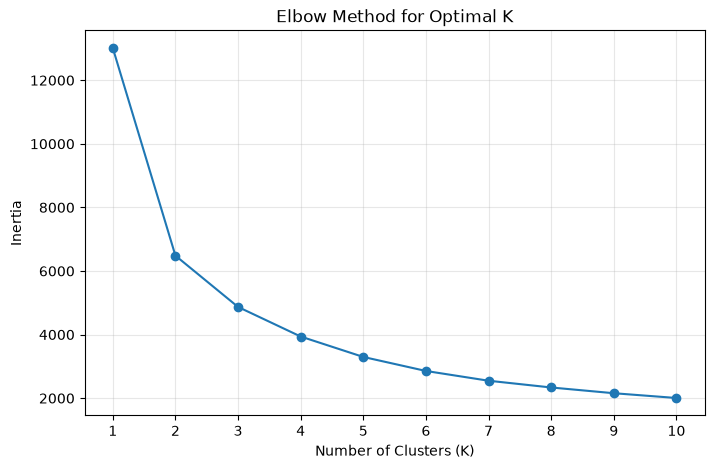

In [115]:
plt.figure(figsize=(8, 5))

plt.plot(K, inertia, marker='o')

plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')
plt.title('Elbow Method for Optimal K')
plt.xticks(K)
plt.grid(alpha=0.3)

plt.show()

**Observation:**  
The elbow curve shows a sharp decrease in inertia from K=1 to K=3, after which the reduction becomes more gradual.
Therefore, K=3 was selected as an appropriate number of clusters for customer segmentation.

In [116]:
# Apply K-Means with 3 clusters
kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10)
rfm['Cluster'] = kmeans.fit_predict(rfm_scaled)
rfm.head()

,CustomerID,Recency,Frequency,Monetary,Cluster
0,12346.0,326,1,77183.60,2
1,12347.0,2,7,4310.00,0
2,12348.0,75,4,1797.24,2
3,12349.0,19,1,1757.55,2
4,12350.0,310,1,334.40,1


## Cluster Profiling

The clusters are profiled using the average Recency, Frequency, and Monetary values of customers in each cluster.
This helps identify the purchasing characteristics and business meaning of each customer segment.

In [117]:
cluster_profile = rfm.groupby('Cluster').agg(
    Avg_Recency=('Recency', 'mean'),
    Avg_Frequency=('Frequency', 'mean'),
    Avg_Monetary=('Monetary', 'mean'),
    Customer_Count=('CustomerID', 'count')
).round(2)
print(cluster_profile)

         Avg_Recency  Avg_Frequency  Avg_Monetary  Customer_Count
Cluster                                                          
0              17.06          13.35       7898.46             769
1             167.36           1.35        361.00            1872
2              44.20           3.38       1259.58            1697


**Cluster Interpretation:**

- **Cluster 0 – High-Value / Loyal Customers:** These customers purchase frequently, have purchased recently,
and generate the highest average monetary value.They represent the most valuable customer segment.

- **Cluster 1 – Inactive / Low-Value Customers:** These customers have the highest recency, lowest purchase frequency,
and lowest monetary value. They represent inactive or low-engagement customers.

- **Cluster 2 – Regular / Potential Loyal Customers:** These customers show moderate recency, frequency, and spending.
They represent regular customers who have the potential to become high-value loyal customers.

In [118]:
cluster_labels = {
    0: 'High-Value / Loyal',
    1: 'Inactive / Low-Value',
    2: 'Regular / Potential Loyal'}
rfm['CustomerType'] = rfm['Cluster'].map(cluster_labels)
rfm.head()

,CustomerID,Recency,Frequency,Monetary,Cluster,CustomerType
0,12346.0,326,1,77183.60,2,Regular / Potential Loyal
1,12347.0,2,7,4310.00,0,High-Value / Loyal
2,12348.0,75,4,1797.24,2,Regular / Potential Loyal
3,12349.0,19,1,1757.55,2,Regular / Potential Loyal
4,12350.0,310,1,334.40,1,Inactive / Low-Value


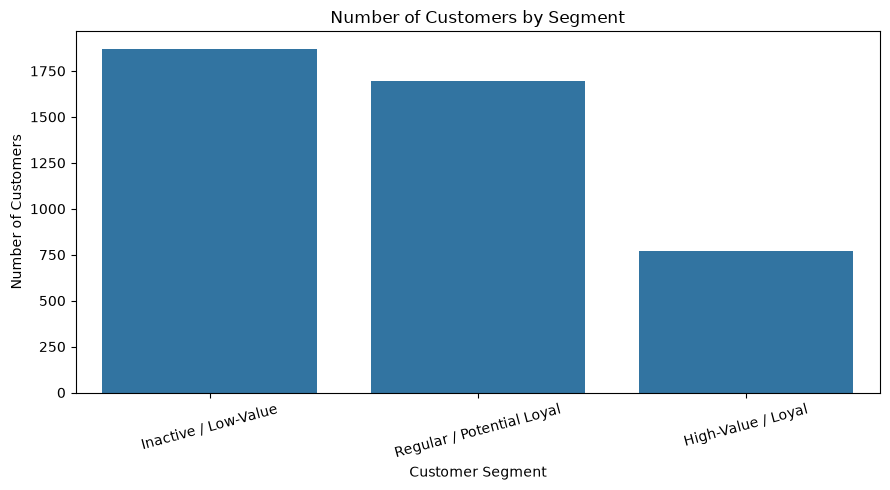

In [119]:
customer_counts = rfm['CustomerType'].value_counts()
plt.figure(figsize=(9, 5))
sns.barplot(
    x=customer_counts.index,
    y=customer_counts.values)

plt.title('Number of Customers by Segment')
plt.xlabel('Customer Segment')
plt.ylabel('Number of Customers')
plt.xticks(rotation=15)

plt.tight_layout()
plt.show()

**Observation:**  
The Inactive / Low-Value segment contains the largest number of customers (1,872), followed by Regular / Potential Loyal customers (1,697). 
The High-Value / Loyal segment is the smallest with 769 customers. This indicates an opportunity to re-engage inactive customers and encourage regular customers to become loyal,high-value customers.

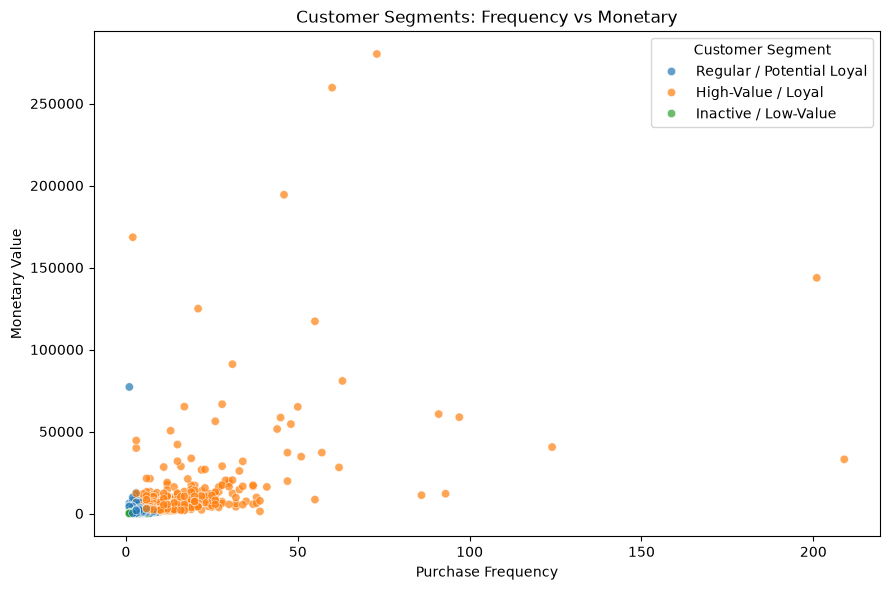

In [120]:
plt.figure(figsize=(9, 6))

sns.scatterplot(
    data=rfm,
    x='Frequency',
    y='Monetary',
    hue='CustomerType',
    alpha=0.7)

plt.title('Customer Segments: Frequency vs Monetary')
plt.xlabel('Purchase Frequency')
plt.ylabel('Monetary Value')
plt.legend(title='Customer Segment')

plt.tight_layout()
plt.show()

**Observation:**  
The Frequency vs Monetary scatter plot shows that High-Value / Loyal customers generally purchase more frequently and generate higher monetary value. Inactive / Low-Value customers are concentrated at low frequency and low spending levels, while Regular / Potential Loyal customers occupy the intermediate range. Several high-value customers also show exceptionally high purchase frequency or spending.

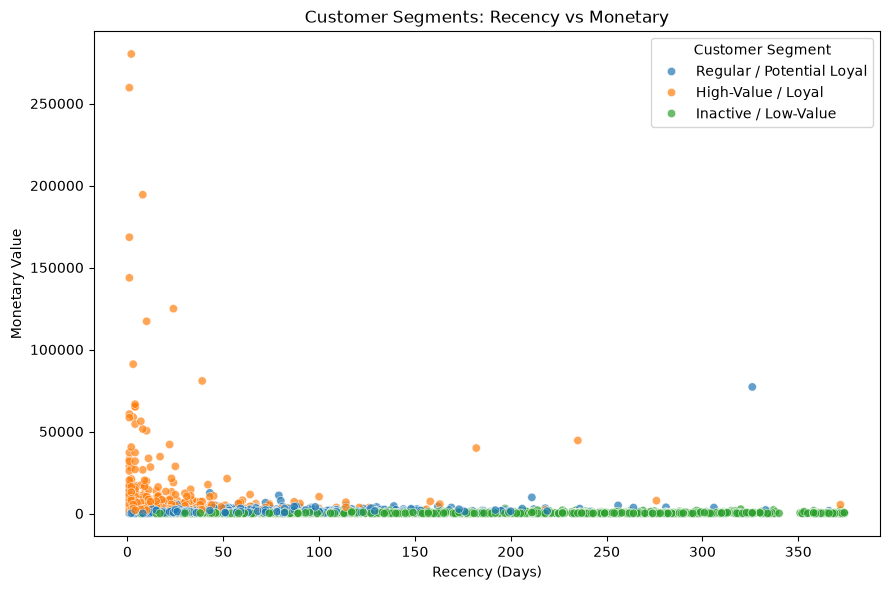

In [121]:
plt.figure(figsize=(9, 6))

sns.scatterplot(
    data=rfm,
    x='Recency',
    y='Monetary',
    hue='CustomerType',
    alpha=0.7)

plt.title('Customer Segments: Recency vs Monetary')
plt.xlabel('Recency (Days)')
plt.ylabel('Monetary Value')
plt.legend(title='Customer Segment')

plt.tight_layout()
plt.show()

**Observation:**  
The Recency vs Monetary scatter plot shows that High-Value / Loyal customers are generally more recent purchasers and tend to generate higher monetary value. Inactive / Low-Value customers tend to have higher recency and lower spending, indicating that they have not purchased for a longer period. Regular / Potential Loyal customers generally fall between these two groups.

## Marketing Recommendations

Based on the RFM customer segmentation, different marketing strategies can be applied to each customer group.

### 1. High-Value / Loyal Customers
- Provide VIP rewards, loyalty points, and exclusive discounts.
- Offer early access to new products and special promotions.
- Use personalized product recommendations based on previous purchases.
- Focus on retention to maintain their high purchase frequency and spending.

### 2. Regular / Potential Loyal Customers
- Encourage repeat purchases through loyalty programs and targeted promotions.
- Provide personalized product recommendations and bundle offers.
- Offer incentives after reaching specific purchase milestones.
- Use cross-selling and upselling strategies to increase customer spending.

### 3. Inactive / Low-Value Customers
- Launch re-engagement campaigns with limited-time discounts or coupons.
- Send personalized reminders and promotional emails.
- Offer incentives for returning and making another purchase.
- Monitor campaign responses and avoid excessive marketing to customers who remain inactive.

## Conclusion

This customer segmentation analysis used RFM features and K-Means clustering to group customers based on purchasing behaviour.

Three customer segments were identified:

- **High-Value / Loyal Customers:** These customers purchase frequently, have purchased recently, and generate the highest monetary value. They are the most valuable segment and should be retained through loyalty rewards, VIP benefits, and personalized offers.

- **Inactive / Low-Value Customers:** These customers have not purchased recently, purchase infrequently, and generate the lowest monetary value. Re-engagement campaigns, discounts, and return incentives may help bring some of these customers back.

- **Regular / Potential Loyal Customers:** These customers show moderate purchasing activity and spending. Targeted promotions, loyalty programs, cross-selling, and personalized recommendations can help convert them into high-value loyal customers.

Overall, RFM analysis combined with K-Means clustering provides a practical approach for understanding customer behaviour and supporting targeted marketing strategies.

### Key Results

- Average Purchase Value: **479.56**
- Average Purchase Frequency: **4.27 orders per customer**
- Average Historical Customer Lifetime Value: **2,048.69**
- Optimal Number of Clusters: **3**
- High-Value / Loyal Customers: **769**
- Inactive / Low-Value Customers: **1,872**
- Regular / Potential Loyal Customers: **1,697**